# Notebook 02 — Input Data Structures and Loading

This notebook walks through every input file and the functions that parse them.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLE_DIR = PROJECT_ROOT / "notebooks" / "sample_data"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 1 · protephospho.csv — dual-row format

In [2]:
df_pp = pd.read_csv(SAMPLE_DIR / "protephospho.csv")
print("Shape:", df_pp.shape)
df_pp.head(8)


Shape: (12, 16)


,GeneID,Psite,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14
0,EGFR,NaN,0.238620,0.661583,0.561625,0.256993,0.218375,0.001000,0.297629,0.679325,1.000000,0.700569,0.342600,0.191126,0.343815,0.493533
1,EGFR,Y1068,0.676981,1.000000,0.986889,0.997060,0.702258,0.611721,0.729335,0.676035,0.513826,0.294383,0.116206,0.001000,0.377601,0.933599
2,EGFR,S1173,0.834016,1.000000,0.971292,0.939213,0.726710,0.551242,0.824882,0.808167,0.617930,0.385087,0.149977,0.001000,0.386786,0.937064
3,EGFR,T992,0.745444,0.954675,0.989117,0.956949,0.745293,0.566586,0.906617,0.916132,0.486997,0.330734,0.094406,0.001000,0.486944,1.000000
4,MET,NaN,0.599926,0.412831,0.168461,0.001000,0.151194,0.403536,0.662757,0.788038,0.585218,0.308136,0.309078,0.501070,0.896752,1.000000
5,MET,Y1068,0.637518,0.807408,0.752220,0.673991,0.529649,0.630519,0.810065,0.784417,0.423224,0.148690,0.098071,0.001000,0.458757,1.000000
6,MET,S1173,0.754156,0.773637,0.690614,0.627147,0.630465,0.628100,0.863584,0.717251,0.389864,0.151440,0.001000,0.083610,0.574132,1.000000
7,MET,T992,0.696445,0.714402,0.622659,0.647284,0.547097,0.661393,0.797364,0.675765,0.345536,0.036236,0.001000,0.141744,0.559231,1.000000


### Dual-row format explained

Each protein appears **twice** per row type:

* **Protein row** — `Psite` is empty (`NaN`); values are the total protein abundance
* **Phosphosite row** — `Psite` is e.g. `"Y1068"`; values are site-specific intensities

`load_site_data()` separates these automatically.


In [3]:
# Show protein rows vs phosphosite rows side by side
mask_prot = df_pp["Psite"].isna()
print(f"Protein rows:     {mask_prot.sum()}")
print(f"Phosphosite rows: {(~mask_prot).sum()}")
print()
print("--- Protein rows (first 3) ---")
print(df_pp[mask_prot].head(3).to_string())
print()
print("--- Phosphosite rows (first 3) ---")
print(df_pp[~mask_prot].head(3).to_string())


Protein rows:     3
Phosphosite rows: 9

--- Protein rows (first 3) ---
  GeneID Psite        x1        x2        x3        x4        x5        x6        x7        x8        x9       x10       x11       x12       x13       x14
0   EGFR   NaN  0.238620  0.661583  0.561625  0.256993  0.218375  0.001000  0.297629  0.679325  1.000000  0.700569  0.342600  0.191126  0.343815  0.493533
4    MET   NaN  0.599926  0.412831  0.168461  0.001000  0.151194  0.403536  0.662757  0.788038  0.585218  0.308136  0.309078  0.501070  0.896752  1.000000
8  ERBB2   NaN  0.186479  0.023415  0.001000  0.255656  0.581707  0.765398  0.611564  0.358304  0.286428  0.347786  0.702949  0.977076  1.000000  0.740007

--- Phosphosite rows (first 3) ---
  GeneID  Psite        x1        x2        x3        x4        x5        x6        x7        x8        x9       x10       x11    x12       x13       x14
1   EGFR  Y1068  0.676981  1.000000  0.986889  0.997060  0.702258  0.611721  0.729335  0.676035  0.513826  0.294383  0.

## 2 · load_site_data() return values

In [4]:
from phoscrosstalk.data_loader import load_site_data

timepoints = list(range(1, 15))   # 14 time points

sites, proteins, site_prot_idx, positions, t, Y, A_data, A_proteins = \
    load_site_data(SAMPLE_DIR / "protephospho.csv", timepoints)

print("Return values from load_site_data():")
print(f"  sites         : {sites}  (list[str], length N={len(sites)})")
print(f"  proteins      : {proteins}  (list[str], length K={len(proteins)})")
print(f"  site_prot_idx : {site_prot_idx}  (ndarray shape ({len(site_prot_idx)},))")
print(f"  positions     : {positions}  (ndarray shape ({len(positions)},))")
print(f"  t             : {t}  (ndarray shape ({len(t)},))")
print(f"  Y             : shape {Y.shape}  → (N_sites × T) phosphosite intensities")
print(f"  A_data        : shape {A_data.shape}  → (K × T) protein abundances")
print(f"  A_proteins    : {A_proteins}")


Return values from load_site_data():
  sites         : ['EGFR_Y1068', 'EGFR_S1173', 'EGFR_T992', 'MET_Y1068', 'MET_S1173', 'MET_T992', 'ERBB2_Y1068', 'ERBB2_S1173', 'ERBB2_T992']  (list[str], length N=9)
  proteins      : ['EGFR', 'ERBB2', 'MET']  (list[str], length K=3)
  site_prot_idx : [0 0 0 2 2 2 1 1 1]  (ndarray shape (9,))
  positions     : [1068. 1173.  992. 1068. 1173.  992. 1068. 1173.  992.]  (ndarray shape (9,))
  t             : [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]  (ndarray shape (14,))
  Y             : shape (9, 14)  → (N_sites × T) phosphosite intensities
  A_data        : shape (3, 14)  → (K × T) protein abundances
  A_proteins    : ['EGFR' 'ERBB2' 'MET']


In [5]:
print("site_prot_idx mapping:")
for s, idx in zip(sites, site_prot_idx):
    print(f"  {s:<18} → protein index {idx}  ({proteins[idx]})")


site_prot_idx mapping:
  EGFR_Y1068         → protein index 0  (EGFR)
  EGFR_S1173         → protein index 0  (EGFR)
  EGFR_T992          → protein index 0  (EGFR)
  MET_Y1068          → protein index 2  (MET)
  MET_S1173          → protein index 2  (MET)
  MET_T992           → protein index 2  (MET)
  ERBB2_Y1068        → protein index 1  (ERBB2)
  ERBB2_S1173        → protein index 1  (ERBB2)
  ERBB2_T992         → protein index 1  (ERBB2)


## 3 · load_rna_data()

In [6]:
from phoscrosstalk.data_loader import load_rna_data

gene_ids, t_rna, rna_matrix = load_rna_data(
    SAMPLE_DIR / "mrna.csv",
    timepoints=list(range(1, 15))
)

print(f"gene_ids   : {gene_ids}")
print(f"t_rna      : {t_rna}  shape {t_rna.shape}")
print(f"rna_matrix : shape {rna_matrix.shape}  → (K × T_rna) mRNA levels")


gene_ids   : ['EGFR', 'MET', 'ERBB2']
t_rna      : [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]  shape (14,)
rna_matrix : shape (3, 14)  → (K × T_rna) mRNA levels


## 4 · kinase_sites.tsv and tf_mrna.csv

In [7]:
df_kin = pd.read_csv(SAMPLE_DIR / "kinase_sites.tsv", sep="\t")
print("kinase_sites.tsv  shape:", df_kin.shape)
print("Columns:", list(df_kin.columns))
df_kin


kinase_sites.tsv  shape: (14, 3)
Columns: ['Site', 'Kinase', 'weight']


,Site,Kinase,weight
0,EGFR_Y1068,MET,0.842946
1,EGFR_Y1068,EGFR,0.157054
2,EGFR_S1173,EGFR,0.679489
3,EGFR_S1173,MET,0.320511
4,EGFR_T992,EGFR,1.000000
5,MET_Y1068,EGFR,0.719285
6,MET_Y1068,MET,0.280715
7,MET_S1173,MET,0.861700
8,MET_S1173,EGFR,0.138300
9,MET_T992,EGFR,1.000000


In [8]:
df_tf = pd.read_csv(SAMPLE_DIR / "tf_mrna.csv")
print("tf_mrna.csv  shape:", df_tf.shape)
print("Columns:", list(df_tf.columns))
df_tf


tf_mrna.csv  shape: (4, 3)
Columns: ['Source', 'Target', 'Weight']


,Source,Target,Weight
0,ERBB2,EGFR,0.747773
1,ERBB2,MET,0.693236
2,MET,MET,0.926073
3,MET,ERBB2,0.873950


## 5 · Annotated shape summary

In [9]:
summary = {
    "Y  (phosphosite data)":   {"shape": str(Y.shape),          "rows": "N phosphosites", "cols": "T time points"},
    "A_data (protein abund.)": {"shape": str(A_data.shape),      "rows": "K proteins",     "cols": "T time points"},
    "rna_matrix (mRNA)":       {"shape": str(rna_matrix.shape),  "rows": "K genes",        "cols": "T_rna time points"},
}
for name, info in summary.items():
    print(f"  {name}: {info['shape']}")
    print(f"    rows → {info['rows']}")
    print(f"    cols → {info['cols']}")


  Y  (phosphosite data): (9, 14)
    rows → N phosphosites
    cols → T time points
  A_data (protein abund.): (3, 14)
    rows → K proteins
    cols → T time points
  rna_matrix (mRNA): (3, 14)
    rows → K genes
    cols → T_rna time points


## 6 · Quick visualisation of loaded data

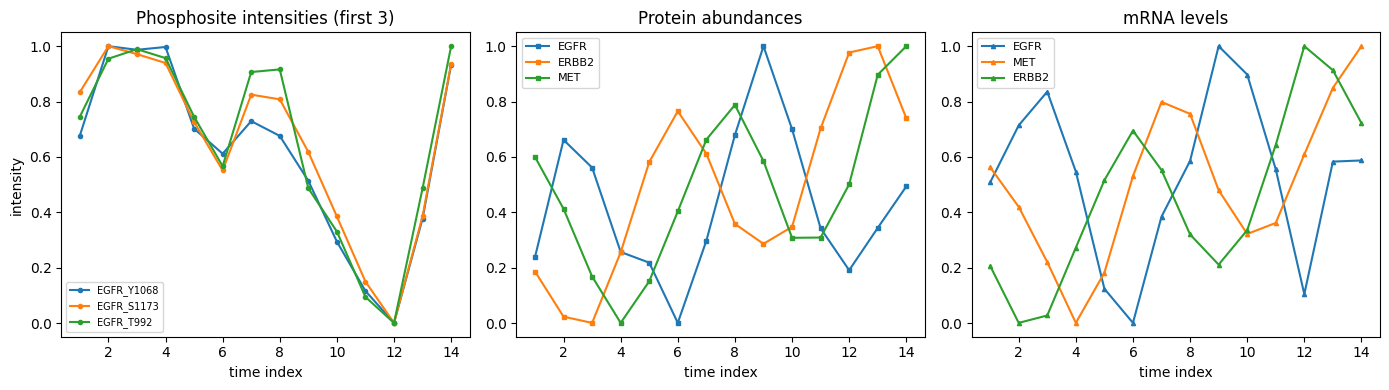

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Phosphosite trajectories
ax = axes[0]
for i, s in enumerate(sites[:3]):
    ax.plot(t, Y[i], marker="o", markersize=3, label=s)
ax.set_title("Phosphosite intensities (first 3)")
ax.set_xlabel("time index")
ax.set_ylabel("intensity")
ax.legend(fontsize=7)

# Protein abundance trajectories
ax = axes[1]
for k in range(A_data.shape[0]):
    ax.plot(t, A_data[k], marker="s", markersize=3, label=proteins[k])
ax.set_title("Protein abundances")
ax.set_xlabel("time index")
ax.legend(fontsize=8)

# mRNA trajectories
ax = axes[2]
for g, gene in enumerate(gene_ids):
    ax.plot(t_rna, rna_matrix[g], marker="^", markersize=3, label=gene)
ax.set_title("mRNA levels")
ax.set_xlabel("time index")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_raw_trajectories.png", dpi=100)
plt.show()
